# V2 Pipeline - Phase 1: Phân tích Khám phá Dữ liệu (EDA) & Kỹ thuật Đặc trưng (Feature Engineering)

Theo chỉ đạo góp ý từ chuyên gia Nguyễn Văn Vượng, giai đoạn này thực hiện:
1. **Rà soát biến phân loại (Categorical)**: Áp dụng One-Hot Encoding cho các biến thuộc tính phân loại thay vì nén Z-score.
2. **Phân tích độ biến thiên (Variance Analysis)**: Khảo sát độ biến thiên (Variance & Std Dev) của các đặc trưng thô khi chưa chuẩn hóa.
3. **Xử lý Khuyết thiếu & Nhiễu**: Áp dụng Mean Imputation (`SimpleImputer(strategy='mean')`).
4. **Tạo 2 Bộ Đặc trưng Scaled V2**: So sánh **Min-Max Scaling** (đưa dữ liệu về `[0, 1]`) vs **Z-Score Normalization**.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import warnings
warnings.filterwarnings('ignore')

print('✅ Nạp thành công các thư viện EDA & Preprocessing V2!')


✅ Nạp thành công các thư viện EDA & Preprocessing V2!


### 1. Nạp Bộ Dữ Liệu Thô & Kiểm tra Biến Phân Loại (Categorical Features Check)

In [2]:
data_candidates = [
    '../../data/features/combined_mimic_ptbxl_advanced.csv',
    '../../data/features/mimic_train_features_advanced.csv',
    'data/features/combined_mimic_ptbxl_advanced.csv',
    'data/features/mimic_train_features_advanced.csv'
]
data_path = next((p for p in data_candidates if os.path.exists(p)), None)

df_raw = pd.read_csv(data_path)
print(f"Nạp dữ liệu thành công từ: {data_path}")
print(f"Kích thước dữ liệu thô: {df_raw.shape[0]} mẫu | {df_raw.shape[1]} cột")

# Kiểm tra các cột dạng thuộc tính (Categorical/Object)
cat_cols = df_raw.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Các cột thuộc tính phân loại (Categorical): {cat_cols}")

if cat_cols:
    df_processed = pd.get_dummies(df_raw, columns=cat_cols, drop_first=True)
    print(f"✅ Đã áp dụng One-Hot Encoding cho các biến phân loại!")
else:
    df_processed = df_raw.copy()
    print("ℹ️ Tất cả các đặc trưng đều là dạng số (Numerical Features).")


Nạp dữ liệu thành công từ: ../../data/features/combined_mimic_ptbxl_advanced.csv
Kích thước dữ liệu thô: 4230 mẫu | 17 cột
Các cột thuộc tính phân loại (Categorical): []
ℹ️ Tất cả các đặc trưng đều là dạng số (Numerical Features).


### 2. Kiểm tra Độ Biến Thiên của Dữ Liệu Thô (Variance & Std Dev Analysis)

In [3]:
feature_cols = [c for c in df_processed.columns if c != 'status']
X_raw = df_processed[feature_cols]
y = df_processed['status']

stats_df = pd.DataFrame({
    'Mean': X_raw.mean(),
    'Std_Dev': X_raw.std(),
    'Variance': X_raw.var(),
    'Min': X_raw.min(),
    'Max': X_raw.max(),
    'Range': X_raw.max() - X_raw.min()
}).sort_values(by='Variance', ascending=False)

print("--- BẢNG THỐNG KÊ ĐỘ BIẾN THIÊN CÁC ĐẶC TRƯNG THÔ (LÚC CHƯA CHUẨN HÓA) ---\n")
print(stats_df.round(4).to_string())


--- BẢNG THỐNG KÊ ĐỘ BIẾN THIÊN CÁC ĐẶC TRƯNG THÔ (LÚC CHƯA CHUẨN HÓA) ---

                 Mean   Std_Dev    Variance       Min        Max     Range
Mean_NN      719.2111  153.5582  23580.1168  430.4545  1358.5714  928.1169
RMSSD        156.9723  106.3364  11307.4275    2.8868   691.7986  688.9118
SD2          125.5062   82.7880   6853.8563    2.3751   542.6469  540.2718
SDNN         121.9456   78.1513   6107.6215    2.5820   520.0803  517.4983
SD1          113.8804   77.6615   6031.3043    2.0412   488.4410  486.3998
HF_norm       19.7763   33.0018   1089.1213    0.0000    99.8879   99.8879
pNN50         49.1512   31.9168   1018.6803    0.0000   100.0000  100.0000
HR_mean       86.9636   17.1258    293.2929   44.1640   139.3875   95.2235
LF_norm        8.6398   17.0804    291.7408    0.0000    93.7846   93.7846
NN50          10.2539   10.3776    107.6943    0.0000    47.0000   47.0000
CV             4.7598    9.6682     93.4741    0.0041    58.9153   58.9112
SampEn         0.6767   

### 3. Xử lý Missing Values (Mean Imputation) & Chuẩn hóa Dữ liệu (Min-Max vs Z-Score)

In [4]:
# 1. Mean Imputation (Xử lý nhiễu & giá trị khuyết theo khuyến nghị)
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_raw)
X_imputed_df = pd.DataFrame(X_imputed, columns=feature_cols)

# 2. Min-Max Scaling [0, 1] (Thử nghiệm phương pháp biến đổi Min-Max)
minmax_scaler = MinMaxScaler()
X_minmax = minmax_scaler.fit_transform(X_imputed_df)
df_minmax = pd.DataFrame(X_minmax, columns=feature_cols)
df_minmax['status'] = y.values

# 3. Z-Score Normalization (StandardScaler)
zscore_scaler = StandardScaler()
X_zscore = zscore_scaler.fit_transform(X_imputed_df)
df_zscore = pd.DataFrame(X_zscore, columns=feature_cols)
df_zscore['status'] = y.values

# Lưu trữ 2 bộ dữ liệu V2 ra thư mục data/features
save_dir_candidates = ['../../data/features', 'data/features']
save_dir = next((d for d in save_dir_candidates if os.path.exists(os.path.dirname(d))), '../../data/features')
os.makedirs(save_dir, exist_ok=True)

path_minmax = os.path.join(save_dir, 'v2_minmax_scaled.csv')
path_zscore = os.path.join(save_dir, 'v2_zscore_scaled.csv')

df_minmax.to_csv(path_minmax, index=False)
df_zscore.to_csv(path_zscore, index=False)

print(f"✅ Đã lưu tập Min-Max Scaled V2 vào: {path_minmax}")
print(f"✅ Đã lưu tập Z-Score Scaled V2 vào: {path_zscore}")


✅ Đã lưu tập Min-Max Scaled V2 vào: ../../data/features\v2_minmax_scaled.csv
✅ Đã lưu tập Z-Score Scaled V2 vào: ../../data/features\v2_zscore_scaled.csv


### 4. Trực quan hóa So sánh Biên độ Dữ liệu Thô vs Min-Max vs Z-Score

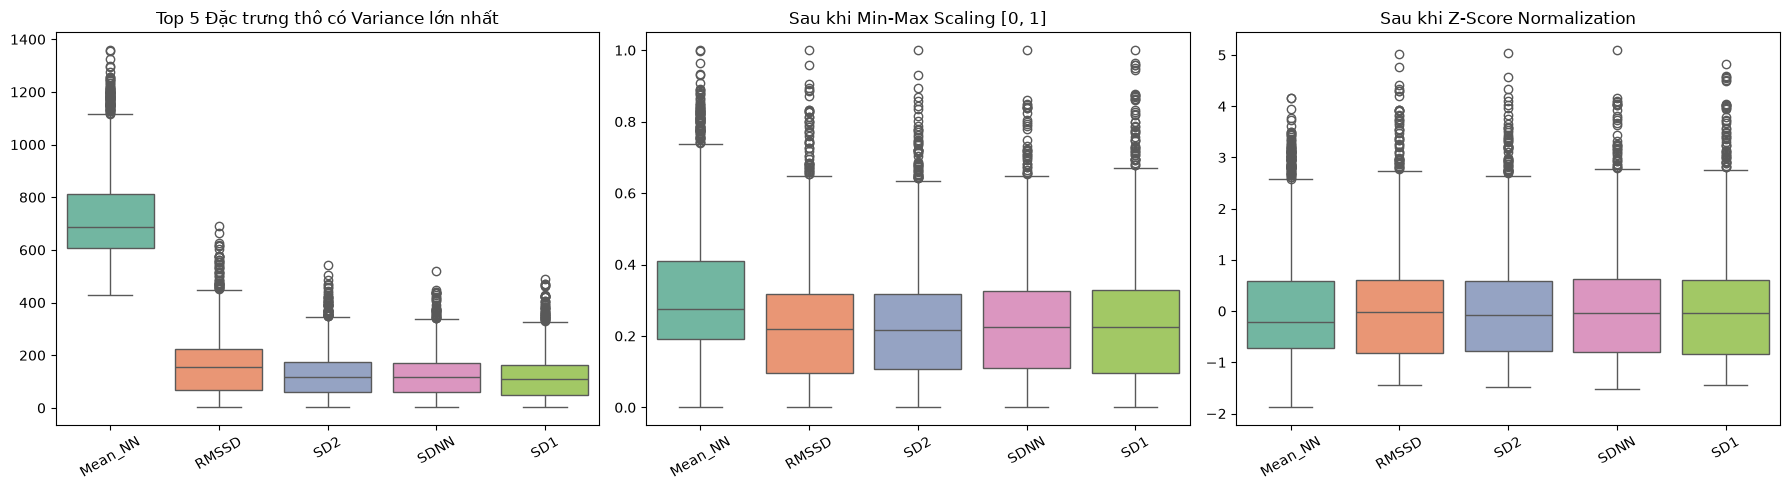

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
top_5_var_cols = stats_df.index[:5].tolist()

sns.boxplot(data=X_raw[top_5_var_cols], ax=axes[0], palette='Set2')
axes[0].set_title('Top 5 Đặc trưng thô có Variance lớn nhất')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df_minmax[top_5_var_cols], ax=axes[1], palette='Set2')
axes[1].set_title('Sau khi Min-Max Scaling [0, 1]')
axes[1].tick_params(axis='x', rotation=30)

sns.boxplot(data=df_zscore[top_5_var_cols], ax=axes[2], palette='Set2')
axes[2].set_title('Sau khi Z-Score Normalization')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()
